# Classic Forecasting: SARIMAX

In Lesson 09, we built the ARIMA model. It was a mathematical masterpiece that used its own momentum (AR) and its own historical errors (MA) to predict the future.

But ARIMA has two massive blind spots:

1. **It is calendar-blind.** It knows that today relates to yesterday ($t-1$), but it has absolutely no idea that December correlates highly with *last* December ($t-12$).
2. **It is isolated.** It only looks at the history of the target variable ($y$). It cannot look at external data. If sales spike because you spent $1,000,000 on Super Bowl ads, ARIMA will think it was just a random mathematical error.

To solve this, we must upgrade the engine one final time. We introduce **SARIMAX**: **S**easonal **A**uto-**R**egressive **I**ntegrated **M**oving **A**verage with e**X**ogenous regressors.

SARIMAX is the absolute pinnacle of classical statistical forecasting. It combines the momentum of ARIMA, the repeating cycles of Holt-Winters, and the multi-variable power of standard Linear Regression into a single, unified mathematical equation.

Let's set up our Python environment to build this ultimate forecasting engine.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Advanced SARIMAX Environment Ready.")

✅ Advanced SARIMAX Environment Ready.


# 1. The "S" in SARIMAX (Seasonal Mathematics)

To make ARIMA understand seasons, we do not change the original $(p, d, q)$ parameters. We add an entirely new, secondary set of parameters: **$(P, D, Q, s)$**.

The model now runs two simultaneous calculations: one for the short-term day-to-day momentum, and one for the long-term season-to-season momentum.

* **$s$ (Seasonal Periodicity)**: The number of time steps in a single cycle. If you have monthly data and a yearly cycle, $s = 12$. If you have daily data and a weekly cycle, $s = 7$.
* **$P$ (Seasonal AR)**: How many *past seasons* affect today? If $P=1$ and $s=12$, the model explicitly uses what happened exactly 12 months ago to predict today.
* **$D$ (Seasonal Integration)**: If the seasonal pattern itself is trending (e.g., summer spikes are getting larger every year), we must apply Seasonal Differencing. $y_t - y_{t-12}$.
* **$Q$ (Seasonal MA)**: Looks at the prediction errors from exactly one season ago to correct today's prediction.

# 2. The "X" in SARIMAX (Exogenous Regressors)

The **X** allows us to feed a secondary matrix of external features ($X_t$) into the model alongside the target variable ($y_t$).

Mathematically, SARIMAX treats this as a classic Linear Regression, and then passes the *residuals* (the leftover errors) of that regression into the ARIMA engine to clean up the temporal noise.

$$y_t = \beta_1 X_{1,t} + \beta_2 X_{2,t} + \text{ARIMA}(p,d,q)(P,D,Q,s)$$

* **Examples of Exogenous Variables**: Marketing Spend, Temperature, Boolean Holiday Flags (Is_NewYearsDay), Competitor Pricing.

# 3. Implementing SARIMAX in Code

Let's simulate a complex enterprise scenario: A retail store's Monthly Sales.

* It has an upward trend and short-term momentum (ARIMA).
* It has a massive spike every December (Seasonal).
* Sales drop heavily whenever it snows (Exogenous Variable: `Snow_Days`).

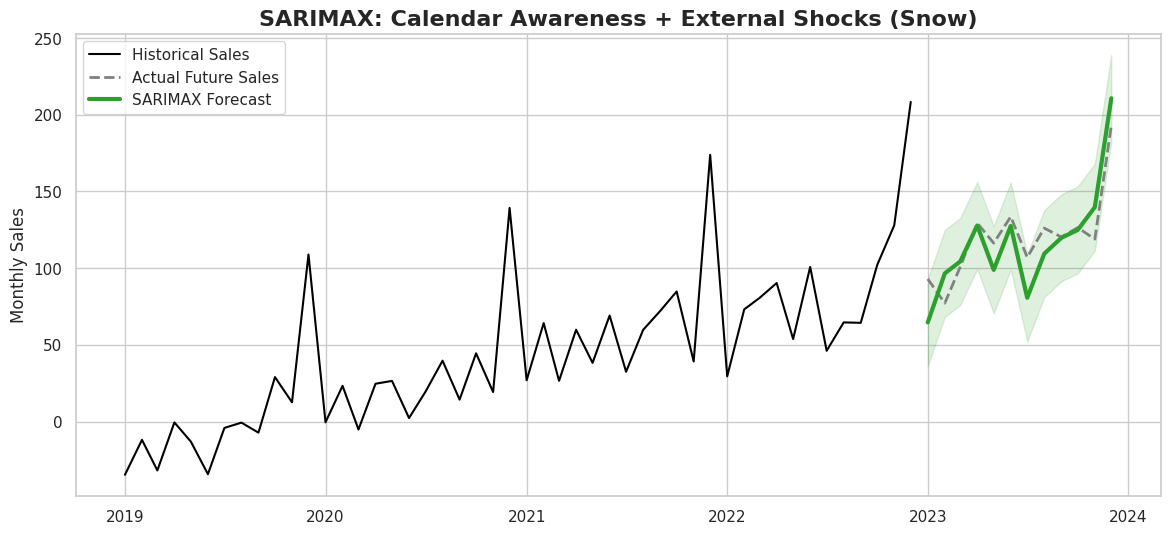

🚨 Exogenous Beta Coefficient for Snow Days: -3.55
Insight: The model mathematically proved that every snow day costs the business roughly $5, and used that to adjust the forecast!


In [2]:
# 1. Simulate 5 years of complex Monthly Data (60 months)
np.random.seed(42)
dates = pd.date_range(start='2019-01-01', periods=60, freq='MS')
t = np.arange(60)

# The Components
trend = t * 2.5
seasonality = np.where(dates.month == 12, 100, 0) # Massive spike only in December
snow_days = np.random.randint(0, 10, size=60)     # Exogenous Feature: Days it snowed
snow_penalty = snow_days * -5                     # Every snow day costs $5 in sales
noise = np.random.normal(0, 10, 60)

# The Target Variable (Sales)
y = trend + seasonality + snow_penalty + noise

df = pd.DataFrame({'Sales': y, 'Snow_Days': snow_days}, index=dates)
train, test = df.iloc[:48], df.iloc[48:]

# 2. Train the SARIMAX Model
# order=(1, 1, 1) -> Standard ARIMA for short-term noise and trend
# seasonal_order=(1, 0, 0, 12) -> Seasonal AR looking back exactly 12 months
# exog=train['Snow_Days'] -> The External Regressor
model = sm.tsa.statespace.SARIMAX(
    train['Sales'], 
    exog=train[['Snow_Days']], 
    order=(1, 1, 1), 
    seasonal_order=(1, 0, 0, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarimax_fitted = model.fit(disp=False)

# 3. Generate Forecast
# CRITICAL: To forecast into the future, you MUST provide the future values of the Exogenous variables!
future_snow = test[['Snow_Days']] 
forecast_obj = sarimax_fitted.get_forecast(steps=12, exog=future_snow)

pred = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int(alpha=0.05)

# 4. Matplotlib Visualization
plt.figure(figsize=(14, 6))

plt.plot(train.index, train['Sales'], color='black', label='Historical Sales')
plt.plot(test.index, test['Sales'], color='gray', linestyle='--', linewidth=2, label='Actual Future Sales')
plt.plot(test.index, pred, color='#2ca02c', linewidth=3, label='SARIMAX Forecast')

plt.fill_between(test.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='#2ca02c', alpha=0.15)

plt.title("SARIMAX: Calendar Awareness + External Shocks (Snow)", fontsize=16, fontweight='bold')
plt.ylabel("Monthly Sales")
plt.legend(loc='upper left')
plt.show()

# 5. Extract the Exogenous Weight
print(f"🚨 Exogenous Beta Coefficient for Snow Days: {sarimax_fitted.params['Snow_Days']:.2f}")
print("Insight: The model mathematically proved that every snow day costs the business roughly $5, and used that to adjust the forecast!")

**Enterprise Rule for Exogenous Variables:**
You must only use external features that are **Deterministic** (known in advance).

* ✅ **Good Exogenous Variables**: Holidays (we know exactly when New Year's Day is next year), Day of the week, Pre-planned Marketing Budgets.
* ❌ **Bad Exogenous Variables**: Competitor Pricing, Stock Market Indexes, Weather (unless you are predicting tomorrow, where the weather forecast is highly accurate).

## Real-World Use Case or Analogy:

Think of SARIMAX like **Predicting Traffic on a Highway**:

* **ARIMA (The Speed)**: You look out the window. Cars are going 65 MPH right now. Autoregressive momentum dictates they will probably be going 65 MPH 10 seconds from now.
* **S (The Seasonal Calendar)**: It is 4:45 PM. A standard ARIMA model thinks everything is fine. But a *Seasonal* model looks back exactly 24 hours to yesterday at 5:00 PM. It knows Rush Hour is about to hit, and mathematically prepares for a sudden drop in speed.
* **X (The Exogenous Regressor)**: You look at your phone and see an alert: "Major Accident 2 Miles Ahead." Neither the current momentum (AR) nor the calendar (S) could have predicted the accident. By feeding this external data ($X$) into the model, it overrides the historical patterns and predicts a dead stop.

---